In [20]:
from keras import utils
import numpy as np
import tensorflow as tf
from keras.applications import resnet
#from keras.applications import 

In [2]:
!pip install pillow

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [21]:
# Load Keras' ResNet50 model that was pre-trained against the ImageNet database
model = resnet.ResNet50()

# Load the image file, resizing it to 224x224 pixels (required by this model)
## This needs the pillow package. Installed in the previous block of code above.


img = tf.keras.utils.load_img("cat.jpg", target_size=(224, 224))

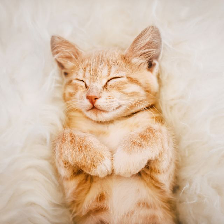

In [22]:
img

In [24]:
# Convert the image to a numpy array
x = tf.keras.utils.img_to_array(img)

In [25]:
x.shape

(224, 224, 3)

In [26]:
x[0]

array([[203., 194., 187.],
       [202., 193., 186.],
       [203., 194., 187.],
       [203., 194., 187.],
       [204., 195., 188.],
       [207., 198., 191.],
       [208., 199., 192.],
       [208., 199., 192.],
       [206., 197., 190.],
       [207., 198., 191.],
       [208., 199., 192.],
       [207., 197., 188.],
       [207., 197., 188.],
       [207., 197., 188.],
       [207., 197., 188.],
       [207., 197., 188.],
       [204., 194., 185.],
       [204., 194., 185.],
       [205., 195., 186.],
       [206., 197., 190.],
       [206., 197., 190.],
       [206., 199., 193.],
       [208., 201., 195.],
       [209., 202., 196.],
       [210., 203., 197.],
       [214., 207., 201.],
       [214., 207., 201.],
       [214., 207., 201.],
       [213., 206., 200.],
       [212., 205., 199.],
       [211., 204., 198.],
       [212., 205., 199.],
       [212., 205., 199.],
       [211., 204., 198.],
       [210., 201., 194.],
       [210., 201., 194.],
       [211., 202., 195.],
 

In [27]:
# Add a fourth dimension since Keras expects a list of images
x = np.expand_dims(x, axis=0)

In [28]:
x.shape

(1, 224, 224, 3)

In [29]:
# Scale the input image to the range used in the trained network
x = resnet.preprocess_input(x)

In [30]:
# Run the image through the deep neural network to make a prediction
predictions = model.predict(x)

1/1 [==============================] - 3s 3s/step


In [31]:
predictions

array([[2.03251352e-06, 1.55765938e-05, 2.85189486e-07, 2.04139724e-06,
        1.83837994e-06, 5.33595339e-05, 1.25101008e-06, 1.09373777e-05,
        1.97598027e-04, 6.08999517e-06, 1.80213840e-06, 1.52382211e-06,
        3.88210128e-06, 1.10255098e-06, 1.09560278e-06, 1.70772728e-05,
        1.42409237e-06, 3.97647500e-06, 2.72247166e-06, 1.91222534e-06,
        3.74019078e-06, 4.74438548e-06, 1.68598963e-05, 2.64617065e-05,
        1.82620679e-05, 1.07234007e-06, 9.92486662e-07, 5.05984553e-06,
        1.58028672e-06, 2.67479390e-06, 1.09516202e-06, 1.20446691e-06,
        2.00228328e-06, 5.62359764e-06, 6.71076032e-06, 1.39591680e-06,
        3.30806506e-06, 1.69268042e-05, 6.72357237e-06, 6.91431387e-06,
        8.21536446e-07, 2.26249394e-05, 3.00581632e-05, 1.54859772e-05,
        4.27337955e-06, 2.23822053e-06, 9.08304355e-06, 4.58622799e-06,
        1.19882759e-06, 1.25123802e-06, 7.76673187e-06, 1.57316981e-06,
        5.79515881e-06, 2.60615798e-06, 2.47767712e-05, 6.802250

In [32]:
# Look up the names of the predicted classes. Index zero is the results for the first image.
predicted_classes = resnet.decode_predictions(predictions, top=5)

In [33]:
predicted_classes

[[('n02124075', 'Egyptian_cat', 0.25542924),
  ('n02127052', 'lynx', 0.15117742),
  ('n02123159', 'tiger_cat', 0.12075856),
  ('n02123045', 'tabby', 0.118202746),
  ('n02123394', 'Persian_cat', 0.084424876)]]

In [34]:
print("This is an image of:")

for imagenet_id, name, likelihood in predicted_classes[0]:
    print(" - {}: {:2f} likelihood".format(name, likelihood))

This is an image of:
 - Egyptian_cat: 0.255429 likelihood
 - lynx: 0.151177 likelihood
 - tiger_cat: 0.120759 likelihood
 - tabby: 0.118203 likelihood
 - Persian_cat: 0.084425 likelihood
